# Portfolio Project: Scrape and analyze data analyst job requirements with Python

This notebook was created as part of the [Coursera Guided Project](https://www.coursera.org/projects/scrape-job-postings-data-analyst) to scrape and analyse job postings data. The goal is to simulate the role of a data analyst at a recruitment agency and explore how web scraping can enhance the process of sourcing job vacancies.

The objective is to play the role of a data analyst at a recruitment agency, helping to improve its sourcing job vacancies. To do this the agency relies on multiple job posting sites to identify potential job openings for its clients. However, manually searching through each site is time-consuming and often leads to missed opportunities.

To address this, we demonstrate how to use web scraping tools to automatically extract job posting data from websites. We then perform analysis on the collected data to uncover insights that can help streamline the job sourcing process. Additionally, we include code to match candidate profiles with job postings that may offer a high likelihood of success—further improving placement effectiveness. This approach enables the agency to deliver relevant openings to clients more efficiently, offering them a competitive edge in the job market.

**Project Objectives**
1. Automate and increase the efficiency of job vacancy sourcing
2. Improve the relevance and quality of job matches
3. Match candidates to job opportunities with high success potential

## Task 1 - Import required Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans
from sklearn.preprocessing import Normalizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

from collections import Counter

import re

from sentence_transformers import SentenceTransformer

import requests
from bs4 import BeautifulSoup

## Task 2 – Scrape the data from Web

We demonstrate how to scrape job posting data using Python-based web scraping tools.

The provided code illustrates how to extract key information such as job title, company, location, and application URL from structured HTML elements. This process forms the foundation for downstream analysis and candidate-job matching.

*Note: The web scraping example provided uses a publicly accessible static website ("https://realpython.github.io/fake-jobs/") designed for educational and testing purposes only. No data is collected from live or commercial websites (e.g., LinkedIn, Indeed, etc.) that prohibit scraping in their terms of service.*

### Extract all job postings from website

In [2]:
URL = "https://realpython.github.io/fake-jobs/"
page = requests.get(URL)

print(page.text)

<!DOCTYPE html>
<html>
  <head>
    <meta charset="utf-8">
    <meta name="viewport" content="width=device-width, initial-scale=1">
    <title>Fake Python</title>
    <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/bulma@0.9.2/css/bulma.min.css">
  </head>
  <body>
  <section class="section">
    <div class="container mb-5">
      <h1 class="title is-1">
        Fake Python
      </h1>
      <p class="subtitle is-3">
        Fake Jobs for Your Web Scraping Journey
      </p>
    </div>
    <div class="container">
    <div id="ResultsContainer" class="columns is-multiline">
    <div class="column is-half">
<div class="card">
  <div class="card-content">
    <div class="media">
      <div class="media-left">
        <figure class="image is-48x48">
          <img src="https://files.realpython.com/media/real-python-logo-thumbnail.7f0db70c2ed2.jpg?__no_cf_polish=1" alt="Real Python Logo">
        </figure>
      </div>
      <div class="media-content">
        <h2 class="title is-

In [3]:
# The content we need is under a <div> with id="ResultsContainer"

soup = BeautifulSoup(page.content, "html.parser")

results = soup.find(id="ResultsContainer")
print(results.prettify())

<div class="columns is-multiline" id="ResultsContainer">
 <div class="column is-half">
  <div class="card">
   <div class="card-content">
    <div class="media">
     <div class="media-left">
      <figure class="image is-48x48">
       <img alt="Real Python Logo" src="https://files.realpython.com/media/real-python-logo-thumbnail.7f0db70c2ed2.jpg?__no_cf_polish=1"/>
      </figure>
     </div>
     <div class="media-content">
      <h2 class="title is-5">
       Senior Python Developer
      </h2>
      <h3 class="subtitle is-6 company">
       Payne, Roberts and Davis
      </h3>
     </div>
    </div>
    <div class="content">
     <p class="location">
      Stewartbury, AA
     </p>
     <p class="is-small has-text-grey">
      <time datetime="2021-04-08">
       2021-04-08
      </time>
     </p>
    </div>
    <footer class="card-footer">
     <a class="card-footer-item" href="https://www.realpython.com" target="_blank">
      Learn
     </a>
     <a class="card-footer-item" href=

In [4]:
# Extract the job postings html

job_cards = results.find_all("div", class_="card-content")
for job_card in job_cards:
    print(job_card, end="\n" * 2)

<div class="card-content">
<div class="media">
<div class="media-left">
<figure class="image is-48x48">
<img alt="Real Python Logo" src="https://files.realpython.com/media/real-python-logo-thumbnail.7f0db70c2ed2.jpg?__no_cf_polish=1"/>
</figure>
</div>
<div class="media-content">
<h2 class="title is-5">Senior Python Developer</h2>
<h3 class="subtitle is-6 company">Payne, Roberts and Davis</h3>
</div>
</div>
<div class="content">
<p class="location">
        Stewartbury, AA
      </p>
<p class="is-small has-text-grey">
<time datetime="2021-04-08">2021-04-08</time>
</p>
</div>
<footer class="card-footer">
<a class="card-footer-item" href="https://www.realpython.com" target="_blank">Learn</a>
<a class="card-footer-item" href="https://realpython.github.io/fake-jobs/jobs/senior-python-developer-0.html" target="_blank">Apply</a>
</footer>
</div>

<div class="card-content">
<div class="media">
<div class="media-left">
<figure class="image is-48x48">
<img alt="Real Python Logo" src="https://fi

In [5]:
# Parse the html into DataFrame

df_fake_postings = []

for job_card in job_cards:
    title_element = job_card.find("h2", class_="title")
    company_element = job_card.find("h3", class_="company")
    location_element = job_card.find("p", class_="location")
    date_element = job_card.find("time")
    link_url = job_card.find_all("a")[1]["href"]
    # print(title_element.text.strip())
    # print(company_element.text.strip())
    # print(location_element.text.strip())
    # print(date_element.text.strip())
    # print(link_url)
    # print()

    df_fake_postings.append(
        {
            "Title": title_element.text.strip(),
            "Company": company_element.text.strip(),
            "Location": location_element.text.strip(),
            "Date": date_element.text.strip(),
            "URL": link_url,
        }
    )

df_fake_postings = pd.DataFrame(df_fake_postings)
df_fake_postings

,Title,Company,Location,Date,URL
0,Senior Python Developer,"Payne, Roberts and Davis","Stewartbury, AA",2021-04-08,https://realpython.github.io/fake-jobs/jobs/se...
1,Energy engineer,Vasquez-Davidson,"Christopherville, AA",2021-04-08,https://realpython.github.io/fake-jobs/jobs/en...
2,Legal executive,"Jackson, Chambers and Levy","Port Ericaburgh, AA",2021-04-08,https://realpython.github.io/fake-jobs/jobs/le...
3,Fitness centre manager,Savage-Bradley,"East Seanview, AP",2021-04-08,https://realpython.github.io/fake-jobs/jobs/fi...
4,Product manager,Ramirez Inc,"North Jamieview, AP",2021-04-08,https://realpython.github.io/fake-jobs/jobs/pr...
...,...,...,...,...,...
95,Museum/gallery exhibitions officer,"Nguyen, Yoder and Petty","Lake Abigail, AE",2021-04-08,https://realpython.github.io/fake-jobs/jobs/mu...
96,"Radiographer, diagnostic",Holder LLC,"Jacobshire, AP",2021-04-08,https://realpython.github.io/fake-jobs/jobs/ra...
97,Database administrator,Yates-Ferguson,"Port Susan, AE",2021-04-08,https://realpython.github.io/fake-jobs/jobs/da...
98,Furniture designer,Ortega-Lawrence,"North Tiffany, AA",2021-04-08,https://realpython.github.io/fake-jobs/jobs/fu...


### Extract Python job postings

In [6]:
python_jobs = results.find_all("h2", string=lambda text: "python" in text.lower())
# print(python_jobs)

python_job_cards = [
    h2_element.parent.parent.parent for h2_element in python_jobs
    ]

In [7]:
for job_card in python_job_cards:
    title_element = job_card.find("h2", class_="title")
    company_element = job_card.find("h3", class_="company")
    location_element = job_card.find("p", class_="location")
    date_element = job_card.find("time")
    link_url = job_card.find_all("a")[1]["href"]
    print(title_element.text.strip())
    print(company_element.text.strip())
    print(location_element.text.strip())
    print(date_element.text.strip())
    print(link_url)
    print()

Senior Python Developer
Payne, Roberts and Davis
Stewartbury, AA
2021-04-08
https://realpython.github.io/fake-jobs/jobs/senior-python-developer-0.html

Software Engineer (Python)
Garcia PLC
Ericberg, AE
2021-04-08
https://realpython.github.io/fake-jobs/jobs/software-engineer-python-10.html

Python Programmer (Entry-Level)
Moss, Duncan and Allen
Port Sara, AE
2021-04-08
https://realpython.github.io/fake-jobs/jobs/python-programmer-entry-level-20.html

Python Programmer (Entry-Level)
Cooper and Sons
West Victor, AE
2021-04-08
https://realpython.github.io/fake-jobs/jobs/python-programmer-entry-level-30.html

Software Developer (Python)
Adams-Brewer
Brockburgh, AE
2021-04-08
https://realpython.github.io/fake-jobs/jobs/software-developer-python-40.html

Python Developer
Rivera and Sons
East Michaelfort, AA
2021-04-08
https://realpython.github.io/fake-jobs/jobs/python-developer-50.html

Back-End Web Developer (Python, Django)
Stewart-Alexander
South Kimberly, AA
2021-04-08
https://realpython

## Task 3 – Process the data

Due to limited information on the static test website, we supplement this project with a publicly available dataset from Kaggle: [LinkedIn Job Postings (2023 - 2024)](https://www.kaggle.com/datasets/arshkon/linkedin-job-postings/code). This allows us to better demonstrate the data analytics process using richer, real-world-like data.

We begin by cleaning and preparing the dataset, which includes extracting relevant fields, handling missing values, and standardizing formats. The dataset contains detailed information about job postings, including job roles, locations, company names, and descriptions. We also consolidate information from multiple sources within the dataset to create a unified view for analysis and candidate-job matching.

### Postings

In [8]:
# The main database that we will append new information to

df_postings_ori = pd.read_csv("archive/postings.csv")
df_postings_ori

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123844,3906267117,Lozano Smith,Title IX/Investigations Attorney,Our Walnut Creek office is currently seeking a...,195000.0,YEARLY,"Walnut Creek, CA",56120.0,1.0,NaN,...,NaN,1.713571e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,94595.0,6013.0
123845,3906267126,Pinterest,"Staff Software Engineer, ML Serving Platform",About Pinterest:\n\nMillions of people across ...,NaN,NaN,United States,1124131.0,3.0,NaN,...,NaN,1.713572e+12,www.pinterestcareers.com,0,FULL_TIME,NaN,NaN,NaN,NaN,NaN
123846,3906267131,EPS Learning,"Account Executive, Oregon/Washington",Company Overview\n\nEPS Learning is a leading ...,NaN,NaN,"Spokane, WA",90552133.0,3.0,NaN,...,NaN,1.713572e+12,epsoperations.bamboohr.com,0,FULL_TIME,NaN,NaN,NaN,99201.0,53063.0
123847,3906267195,Trelleborg Applied Technologies,Business Development Manager,The Business Development Manager is a 'hunter'...,NaN,NaN,"Texas, United States",2793699.0,4.0,NaN,...,NaN,1.713573e+12,NaN,0,FULL_TIME,NaN,NaN,NaN,NaN,NaN


In [9]:
df_postings_ori.columns

Index(['job_id', 'company_name', 'title', 'description', 'max_salary',
       'pay_period', 'location', 'company_id', 'views', 'med_salary',
       'min_salary', 'formatted_work_type', 'applies', 'original_listed_time',
       'remote_allowed', 'job_posting_url', 'application_url',
       'application_type', 'expiry', 'closed_time',
       'formatted_experience_level', 'skills_desc', 'listed_time',
       'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type', 'normalized_salary', 'zip_code', 'fips'],
      dtype='object')

In [10]:
# Identify columns that are useful to provide recommendation to job seekers

df_postings = df_postings_ori[["job_id", "title", "company_id", "company_name", "description", "location",
                                   "pay_period", "min_salary", "med_salary", "max_salary", "currency",
                                   "formatted_work_type", "remote_allowed",
                                   "formatted_experience_level", "skills_desc",
                                #    "original_listed_time", "expiry", 
                                   "views", "applies"]]

df_postings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 17 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   title                       123849 non-null  object 
 2   company_id                  122132 non-null  float64
 3   company_name                122130 non-null  object 
 4   description                 123842 non-null  object 
 5   location                    123849 non-null  object 
 6   pay_period                  36073 non-null   object 
 7   min_salary                  29793 non-null   float64
 8   med_salary                  6280 non-null    float64
 9   max_salary                  29793 non-null   float64
 10  currency                    36073 non-null   object 
 11  formatted_work_type         123849 non-null  object 
 12  remote_allowed              15246 non-null   float64
 13  formatted_expe

In [11]:
# There are few roles with no description, they do not come with skill description as well. Remove them 
display(df_postings[df_postings["description"].isna()])

df_postings = df_postings[~df_postings["description"].isna()]

,job_id,title,company_id,company_name,description,location,pay_period,min_salary,med_salary,max_salary,currency,formatted_work_type,remote_allowed,formatted_experience_level,skills_desc,views,applies
20364,3889203695,Promotional Products Sales Executive,89168038.0,Marketing Graphics,NaN,Northeastern United States,NaN,NaN,NaN,NaN,NaN,Full-time,NaN,NaN,NaN,8.0,NaN
22016,3889495558,Director of Consulting & Insights,31026672.0,Talisman,NaN,"New York, NY",NaN,NaN,NaN,NaN,NaN,Full-time,NaN,NaN,NaN,9.0,NaN
55500,3901910128,Asset Managers,90520144.0,Real Deal Home Solutions,NaN,United States,NaN,NaN,NaN,NaN,NaN,Full-time,1.0,NaN,NaN,5.0,NaN
69767,3902829412,Solar Energy Project Manager,74897369.0,Greenday Finance,NaN,"Laguna Beach, CA",NaN,NaN,NaN,NaN,NaN,Full-time,NaN,NaN,NaN,25.0,2.0
70631,3902841370,Head of Tax,18003437.0,Rooted Wealth,NaN,United States,YEARLY,130000.0,NaN,210000.0,USD,Full-time,1.0,NaN,NaN,5.0,NaN
96726,3904950856,Territory Sales Manager,69200675.0,DESMOS Jewels,NaN,United States,NaN,NaN,NaN,NaN,NaN,Full-time,1.0,NaN,NaN,33.0,6.0
96992,3904953645,Behavioral Health Technician,NaN,NaN,NaN,"Suffolk, VA",NaN,NaN,NaN,NaN,NaN,Full-time,NaN,NaN,NaN,3.0,NaN


In [12]:
# Some postings are not based in USA. Assuming that the job seekers are looking for local roles, we remove them
display( df_postings[(df_postings["currency"] != "USD") & (~df_postings["currency"].isna())])

df_postings = df_postings[ ~((df_postings["currency"] != "USD") & (~df_postings["currency"].isna())) ]

,job_id,title,company_id,company_name,description,location,pay_period,min_salary,med_salary,max_salary,currency,formatted_work_type,remote_allowed,formatted_experience_level,skills_desc,views,applies
8335,3885870216,(US) Project Manager - Enterprise,50625.0,PointClickCare,"For more than 20 years, PointClickCare has bee...",United States,YEARLY,94000.0,NaN,107000.0,CAD,Full-time,1.0,Entry level,NaN,380.0,9.0
19292,3888974657,Civil Litigation Lawyer (Junior/Senior level),2908367.0,gpac,"Reno, NV\n\nCompany Overview\n\nWe are a reput...","Reno, NV",YEARLY,97400.0,NaN,154200.0,CAD,Full-time,NaN,Mid-Senior level,NaN,6.0,NaN
19293,3888974658,Associate Veterinarian,2908367.0,gpac,I am seeking an Associate Veterinarian for a f...,"Kensett, AR",YEARLY,52500.0,NaN,60000.0,BBD,Full-time,NaN,Entry level,NaN,4.0,NaN
19335,3888976416,Commercial Lender,2908367.0,gpac,"A growing, independent bank is looking to add ...","Huntsville, AL",YEARLY,45000.0,NaN,77500.0,BBD,Full-time,NaN,Mid-Senior level,NaN,5.0,NaN
22308,3889710534,German Speaking BDR / SDR,81815.0,Henderson Scott,German speaking | SDR/BDR | Pre IPO Software V...,"Germany, PA",YEARLY,45000.0,NaN,45000.0,EUR,Full-time,NaN,Entry level,NaN,11.0,NaN
22325,3889711148,SDR / BDR,81815.0,Henderson Scott,German speaking | SDR/BDR | Pre IPO Software V...,"Germany, PA",YEARLY,45000.0,NaN,50000.0,EUR,Full-time,1.0,Entry level,NaN,45.0,7.0
28010,3891804969,Teachers (with Relocation Assistance to Melbo...,NaN,NaN,Join a uniquely collaborative school environme...,"New York, United States",YEARLY,77248.0,NaN,114591.0,AUD,Full-time,NaN,NaN,NaN,1.0,NaN
29470,3894295381,Axiom Developer,24440.0,Collabera,This is with one of our Banking client.\nMUST ...,"Whippany, NJ",HOURLY,55.0,NaN,60.0,CAD,Contract,NaN,Mid-Senior level,NaN,4.0,NaN
61581,3901991613,Teachers (with Relocation Assistance to Melbo...,NaN,NaN,Join a uniquely collaborative school environme...,"New York, United States",YEARLY,77248.0,NaN,114591.0,AUD,Full-time,NaN,NaN,NaN,1.0,NaN
63320,3902347641,Sales Executive,705661.0,MPLC,Who are we?\nMPLC is the market leader in non-...,"Ennis, TX",YEARLY,25000.0,NaN,27000.0,EUR,Full-time,NaN,Associate,NaN,NaN,NaN


In [13]:
# Fill in some missing values
df_postings["remote_allowed"] = df_postings["remote_allowed"].fillna(0)
df_postings["remote_allowed"] = df_postings["remote_allowed"].astype(int)
df_postings["views"] = df_postings["views"].fillna(0)
df_postings["applies"] = df_postings["applies"].fillna(0)

In [14]:
# Standardise all salary to yearly

def convert_to_yearly_salary(row, salary_col):
    salary = row[salary_col]
    period = row["pay_period"]

    if pd.isnull(salary) or pd.isnull(period):
        return np.nan

    period = period.lower()
    if period == "hourly":
        return salary * 40 * 52
    elif period == "weekly":
        return salary * 52
    elif period == "biweekly":
        return salary * 26
    elif period == "monthly":
        return salary * 12
    elif period == "yearly":
        return salary
    else:
        return np.nan


df_postings["min_salary_yearly"] = df_postings.apply(lambda row: convert_to_yearly_salary(row, "min_salary"), axis=1)
df_postings["med_salary_yearly"] = df_postings.apply(lambda row: convert_to_yearly_salary(row, "med_salary"), axis=1)
df_postings["max_salary_yearly"] = df_postings.apply(lambda row: convert_to_yearly_salary(row, "max_salary"), axis=1)

In [15]:
for col in ["formatted_work_type", "remote_allowed", "formatted_experience_level"]:
    category_counts = df_postings[col].value_counts()
    display(category_counts)

#     # Plot pie chart
#     fig, axs = plt.subplots(figsize=(4,4))
#     fig.suptitle(col)
#     axs.pie(category_counts, labels=category_counts.index, autopct="%1.1f%%", startangle=90)

# plt.show()

formatted_work_type
Full-time     98793
Contract      12116
Part-time      9696
Temporary      1190
Internship      983
Volunteer       562
Other           487
Name: count, dtype: int64

remote_allowed
0    108586
1     15241
Name: count, dtype: int64

formatted_experience_level
Mid-Senior level    41486
Entry level         36700
Associate            9825
Director             3746
Internship           1449
Executive            1222
Name: count, dtype: int64

The majority of job postings (80%) are for full-time positions. While remote work options do exist, they account for only 12% of the total listings. Additionally, 82% of the roles are targeted at mid-senior level professionals or below, with few openings available for internships.

### Jobs

In [16]:
df_benefits = pd.read_csv("archive/jobs/benefits.csv")
df_job_industries = pd.read_csv("archive/jobs/job_industries.csv")
df_skills = pd.read_csv("archive/jobs/job_skills.csv")
df_salaries = pd.read_csv("archive/jobs/salaries.csv")

display(df_benefits)
display(df_job_industries)
display(df_skills)
display(df_salaries)

,job_id,inferred,type
0,3887473071,0,Medical insurance
1,3887473071,0,Vision insurance
2,3887473071,0,Dental insurance
3,3887473071,0,401(k)
4,3887473071,0,Student loan assistance
...,...,...,...
67938,3902878689,0,Dental insurance
67939,3902878689,0,Pension plan
67940,3902878689,0,Tuition assistance
67941,3902878689,0,Disability insurance


,job_id,industry_id
0,3884428798,82
1,3887473071,48
2,3887465684,41
3,3887467939,82
4,3887467939,80
...,...,...
164803,3902882321,104
164804,3902879720,27
164805,3902876855,80
164806,3902878689,116


,job_id,skill_abr
0,3884428798,MRKT
1,3884428798,PR
2,3884428798,WRT
3,3887473071,SALE
4,3887465684,FIN
...,...,...
213763,3902876855,HR
213764,3902878689,MGMT
213765,3902878689,MNFC
213766,3902883233,SALE


,salary_id,job_id,max_salary,med_salary,min_salary,pay_period,currency,compensation_type
0,1,3884428798,NaN,20.0,NaN,HOURLY,USD,BASE_SALARY
1,2,3887470552,25.00,NaN,23.0,HOURLY,USD,BASE_SALARY
2,3,3884431523,120000.00,NaN,100000.0,YEARLY,USD,BASE_SALARY
3,4,3884911725,200000.00,NaN,10000.0,YEARLY,USD,BASE_SALARY
4,5,3887473220,35.00,NaN,33.0,HOURLY,USD,BASE_SALARY
...,...,...,...,...,...,...,...,...
40780,40781,3902881498,NaN,15.5,NaN,HOURLY,USD,BASE_SALARY
40781,40782,3902883232,NaN,25.0,NaN,HOURLY,USD,BASE_SALARY
40782,40783,3902866633,21.53,NaN,21.1,HOURLY,USD,BASE_SALARY
40783,40784,3902879720,125000.00,NaN,100000.0,YEARLY,USD,BASE_SALARY


In [17]:
df_industries_map = pd.read_csv("archive/mappings/industries.csv")
df_skills_map = pd.read_csv("archive/mappings/skills.csv")

display(df_industries_map)
display(df_skills_map)

df_job_industries = pd.merge(df_job_industries, df_industries_map, on="industry_id")
df_skills = pd.merge(df_skills, df_skills_map, on="skill_abr")

,industry_id,industry_name
0,1,Defense and Space Manufacturing
1,3,Computer Hardware Manufacturing
2,4,Software Development
3,5,Computer Networking Products
4,6,"Technology, Information and Internet"
...,...,...
417,3249,Surveying and Mapping Services
418,3250,Retail Pharmacies
419,3251,Climate Technology Product Manufacturing
420,3252,Climate Data and Analytics


,skill_abr,skill_name
0,ART,Art/Creative
1,DSGN,Design
2,ADVR,Advertising
3,PRDM,Product Management
4,DIST,Distribution
5,EDU,Education
6,TRNG,Training
7,PRJM,Project Management
8,CNSL,Consulting
9,PRCH,Purchasing


In [18]:
# Some industries are not found. Remove them
df_job_industries = df_job_industries[~df_job_industries["industry_name"].isna()]

In [19]:
# Merge the industry and skills

df_temp = df_job_industries.groupby('job_id')['industry_name'].apply(lambda x: '; '.join(x)).reset_index()
df_postings_merged = pd.merge(df_postings, df_temp, on='job_id', how='left')

df_temp = df_skills.groupby('job_id')['skill_name'].apply(lambda x: '; '.join(x)).reset_index()
df_postings_merged = pd.merge(df_postings_merged, df_temp, on='job_id', how='left')

df_postings_merged

,job_id,title,company_id,company_name,description,location,pay_period,min_salary,med_salary,max_salary,...,remote_allowed,formatted_experience_level,skills_desc,views,applies,min_salary_yearly,med_salary_yearly,max_salary_yearly,industry_name,skill_name
0,921716,Marketing Coordinator,2774458.0,Corcoran Sawyer Smith,Job descriptionA leading real estate firm in N...,"Princeton, NJ",HOURLY,17.0,NaN,20.0,...,0,NaN,Requirements: \n\nWe are seeking a College or ...,20.0,2.0,35360.0,NaN,41600.0,Real Estate,Marketing; Sales
1,1829192,Mental Health Therapist/Counselor,NaN,NaN,"At Aspen Therapy and Wellness , we are committ...","Fort Collins, CO",HOURLY,30.0,NaN,50.0,...,0,NaN,NaN,1.0,0.0,62400.0,NaN,104000.0,NaN,Health Care Provider
2,10998357,Assitant Restaurant Manager,64896719.0,The National Exemplar,The National Exemplar is accepting application...,"Cincinnati, OH",YEARLY,45000.0,NaN,65000.0,...,0,NaN,We are currently accepting resumes for FOH - A...,8.0,0.0,45000.0,NaN,65000.0,Restaurants,Management; Manufacturing
3,23221523,Senior Elder Law / Trusts and Estates Associat...,766262.0,"Abrams Fensterman, LLP",Senior Associate Attorney - Elder Law / Trusts...,"New Hyde Park, NY",YEARLY,140000.0,NaN,175000.0,...,0,NaN,This position requires a baseline understandin...,16.0,0.0,140000.0,NaN,175000.0,Law Practice,Other
4,35982263,Service Technician,NaN,NaN,Looking for HVAC service tech with experience ...,"Burlington, IA",YEARLY,60000.0,NaN,80000.0,...,0,NaN,NaN,3.0,0.0,60000.0,NaN,80000.0,Facilities Services,Information Technology
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123822,3906267117,Title IX/Investigations Attorney,56120.0,Lozano Smith,Our Walnut Creek office is currently seeking a...,"Walnut Creek, CA",YEARLY,120000.0,NaN,195000.0,...,0,Mid-Senior level,NaN,1.0,0.0,120000.0,NaN,195000.0,Law Practice,Legal; Business Development
123823,3906267126,"Staff Software Engineer, ML Serving Platform",1124131.0,Pinterest,About Pinterest:\n\nMillions of people across ...,United States,NaN,NaN,NaN,NaN,...,1,Mid-Senior level,NaN,3.0,0.0,NaN,NaN,NaN,"Technology, Information and Internet; Software...",Engineering; Information Technology
123824,3906267131,"Account Executive, Oregon/Washington",90552133.0,EPS Learning,Company Overview\n\nEPS Learning is a leading ...,"Spokane, WA",NaN,NaN,NaN,NaN,...,1,Mid-Senior level,NaN,3.0,0.0,NaN,NaN,NaN,Education Administration Programs,Sales; Business Development
123825,3906267195,Business Development Manager,2793699.0,Trelleborg Applied Technologies,The Business Development Manager is a 'hunter'...,"Texas, United States",NaN,NaN,NaN,NaN,...,1,NaN,NaN,4.0,0.0,NaN,NaN,NaN,Industrial Machinery Manufacturing,Business Development; Sales


In [20]:
# Some salaries info are found in different sources. identify them

df_salaries_temp = df_salaries.copy()
df_salaries_temp.columns = [x+"_2" for x in df_salaries_temp.columns]
df_salaries_temp = df_salaries_temp.rename(columns={"job_id_2":"job_id"})

merged = pd.merge(df_postings_merged, df_salaries_temp, on='job_id', how='left')

# Indicate salary source
def identify_source(row):
    if pd.notna(row['currency']) and pd.notna(row['currency_2']):
        return 'both'
    elif pd.notna(row['currency']):
        return 'df1'
    elif pd.notna(row['currency_2']):
        return 'df2'
    else:
        return 'none'

merged['salary_source'] = merged.apply(identify_source, axis=1)

display(merged["salary_source"].value_counts())

salary_source
none    87770
both    36057
Name: count, dtype: int64

In [21]:
# Available salary info is found in both sources.
# Check if there is discrepancies between both datasets
df_temp = merged[(merged['salary_source']=="both")]

df_temp['min_salary_diff'] = (df_temp['min_salary'] != df_temp['min_salary_2']) & (~df_temp['min_salary'].isna()) & (~df_temp['min_salary_2'].isna())
df_temp['med_salary_diff'] = (df_temp['med_salary'] != df_temp['med_salary_2']) & (~df_temp['med_salary'].isna()) & (~df_temp['med_salary_2'].isna())
df_temp['max_salary_diff'] = (df_temp['max_salary'] != df_temp['max_salary_2']) & (~df_temp['max_salary'].isna()) & (~df_temp['max_salary_2'].isna())
df_temp['currency_diff'] = (df_temp['currency'] != df_temp['currency_2']) & (~df_temp['currency'].isna()) & (~df_temp['currency_2'].isna())
df_temp['pay_period_diff'] = (df_temp['pay_period'] != df_temp['pay_period_2']) & (~df_temp['pay_period'].isna()) & (~df_temp['pay_period_2'].isna())

display(df_temp[df_temp['min_salary_diff'] == True].shape[0])
display(df_temp[df_temp['med_salary_diff'] == True].shape[0])
display(df_temp[df_temp['max_salary_diff'] == True].shape[0])
display(df_temp[df_temp['currency_diff'] == True].shape[0])
display(df_temp[df_temp['pay_period_diff'] == True].shape[0])

C:\Users\mjeat\AppData\Local\Temp\ipykernel_5584\564972117.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp['min_salary_diff'] = (df_temp['min_salary'] != df_temp['min_salary_2']) & (~df_temp['min_salary'].isna()) & (~df_temp['min_salary_2'].isna())
C:\Users\mjeat\AppData\Local\Temp\ipykernel_5584\564972117.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp['med_salary_diff'] = (df_temp['med_salary'] != df_temp['med_salary_2']) & (~df_temp['med_salary'].isna()) & (~df_temp['med_salary_2'

0

0

0

0

0

The salary data are identical.

### Companies

In [22]:
df_companies = pd.read_csv("archive/companies/companies.csv")
df_comp_industries = pd.read_csv("archive/companies/company_industries.csv")
df_comp_specialities = pd.read_csv("archive/companies/company_specialities.csv")
df_e_counts = pd.read_csv("archive/companies/employee_counts.csv")

display(df_companies)
display(df_comp_industries)
display(df_comp_specialities)
display(df_e_counts)

,company_id,name,description,company_size,state,country,city,zip_code,address,url
0,1009,IBM,"At IBM, we do more than work. We create. We cr...",7.0,NY,US,"Armonk, New York",10504,International Business Machines Corp.,https://www.linkedin.com/company/ibm
1,1016,GE HealthCare,Every day millions of people feel the impact o...,7.0,0,US,Chicago,0,-,https://www.linkedin.com/company/gehealthcare
2,1025,Hewlett Packard Enterprise,Official LinkedIn of Hewlett Packard Enterpris...,7.0,Texas,US,Houston,77389,1701 E Mossy Oaks Rd Spring,https://www.linkedin.com/company/hewlett-packa...
3,1028,Oracle,We’re a cloud technology company that provides...,7.0,Texas,US,Austin,78741,2300 Oracle Way,https://www.linkedin.com/company/oracle
4,1033,Accenture,Accenture is a leading global professional ser...,7.0,0,IE,Dublin 2,0,Grand Canal Harbour,https://www.linkedin.com/company/accenture
...,...,...,...,...,...,...,...,...,...,...
24468,103463217,JRC Services,NaN,2.0,0,0,0,0,0,https://www.linkedin.com/company/jrcservices
24469,103466352,Centent Consulting LLC,Centent Consulting LLC is a reputable human re...,NaN,0,0,0,0,0,https://www.linkedin.com/company/centent-consu...
24470,103467540,"Kings and Queens Productions, LLC",We are a small but mighty collection of thinke...,NaN,0,0,0,0,0,https://www.linkedin.com/company/kings-and-que...
24471,103468936,WebUnite,Our mission at WebUnite is to offer experience...,NaN,Pennsylvania,US,Southampton,18966,720 2nd Street Pike,https://www.linkedin.com/company/webunite


,company_id,industry
0,391906,Book and Periodical Publishing
1,22292832,Construction
2,20300,Banking
3,3570660,Book and Periodical Publishing
4,878353,Staffing and Recruiting
...,...,...
24370,32313,Retail Luxury Goods and Jewelry
24371,15225088,IT Services and IT Consulting
24372,2852377,Hospitality
24373,19114724,Construction


,company_id,speciality
0,22292832,window replacement
1,22292832,patio door replacement
2,20300,Commercial Banking
3,20300,Retail Banking
4,20300,Mortgage
...,...,...
169382,8060959,Intermodal freight transport
169383,8060959,Inland Transportation
169384,8060959,Roll-on/Roll-off Cargo
169385,8060959,Cargo Handling


,company_id,employee_count,follower_count,time_recorded
0,391906,186,32508,1712346173
1,22292832,311,4471,1712346173
2,20300,1053,6554,1712346173
3,3570660,383,35241,1712346173
4,878353,52,26397,1712346173
...,...,...,...,...
35782,2852377,1999,7943,1713572859
35783,64379,144,31910,1713572859
35784,19114724,4,102,1713572859
35785,307079,602,32199,1713572859


In [23]:
# Merge companies info

df_temp = df_comp_industries.groupby('company_id')['industry'].apply(lambda x: '; '.join(x)).reset_index()
df_companies_comb = pd.merge(df_companies, df_temp, on="company_id")

df_temp = df_comp_specialities.groupby('company_id')['speciality'].apply(lambda x: '; '.join(x)).reset_index()
df_companies_comb = pd.merge(df_companies_comb, df_temp, on="company_id")

df_companies_comb = df_companies_comb[["company_id", "company_size", "industry", "speciality"]]

df_companies_comb.columns = ["company_id", "company_size", "company_industry", "company_speciality"]

df_companies_comb

,company_id,company_size,company_industry,company_speciality
0,1009,7.0,IT Services and IT Consulting,Cloud; Mobile; Cognitive; Security; Research; ...
1,1016,7.0,Hospitals and Health Care,Healthcare; Biotechnology
2,1028,7.0,IT Services and IT Consulting,enterprise; software; applications; database; ...
3,1033,7.0,Business Consulting and Services,Management Consulting; Systems Integration and...
4,1035,7.0,Software Development,Business Software; Developer Tools; Home & Edu...
...,...,...,...,...
17775,103399562,NaN,Environmental Services,Dumpster Rentals; Waste Management; Cardboard ...
17776,103410956,2.0,Construction,site prep; underground utilities; pump station...
17777,103414908,NaN,Financial Services,financial planning; wealth management; financi...
17778,103449231,1.0,Real Estate,HOA Management; Condo Management; Property Man...


In [24]:
# The consolidated dataset for further analysis

df_final_ori = pd.merge(df_postings_merged, df_companies_comb, on="company_id", how="left")
df_final_ori

,job_id,title,company_id,company_name,description,location,pay_period,min_salary,med_salary,max_salary,...,views,applies,min_salary_yearly,med_salary_yearly,max_salary_yearly,industry_name,skill_name,company_size,company_industry,company_speciality
0,921716,Marketing Coordinator,2774458.0,Corcoran Sawyer Smith,Job descriptionA leading real estate firm in N...,"Princeton, NJ",HOURLY,17.0,NaN,20.0,...,20.0,2.0,35360.0,NaN,41600.0,Real Estate,Marketing; Sales,2.0,Real Estate,real estate; new development
1,1829192,Mental Health Therapist/Counselor,NaN,NaN,"At Aspen Therapy and Wellness , we are committ...","Fort Collins, CO",HOURLY,30.0,NaN,50.0,...,1.0,0.0,62400.0,NaN,104000.0,NaN,Health Care Provider,NaN,NaN,NaN
2,10998357,Assitant Restaurant Manager,64896719.0,The National Exemplar,The National Exemplar is accepting application...,"Cincinnati, OH",YEARLY,45000.0,NaN,65000.0,...,8.0,0.0,45000.0,NaN,65000.0,Restaurants,Management; Manufacturing,NaN,NaN,NaN
3,23221523,Senior Elder Law / Trusts and Estates Associat...,766262.0,"Abrams Fensterman, LLP",Senior Associate Attorney - Elder Law / Trusts...,"New Hyde Park, NY",YEARLY,140000.0,NaN,175000.0,...,16.0,0.0,140000.0,NaN,175000.0,Law Practice,Other,2.0,Law Practice,Civil Litigation; Corporate & Securities Law; ...
4,35982263,Service Technician,NaN,NaN,Looking for HVAC service tech with experience ...,"Burlington, IA",YEARLY,60000.0,NaN,80000.0,...,3.0,0.0,60000.0,NaN,80000.0,Facilities Services,Information Technology,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123822,3906267117,Title IX/Investigations Attorney,56120.0,Lozano Smith,Our Walnut Creek office is currently seeking a...,"Walnut Creek, CA",YEARLY,120000.0,NaN,195000.0,...,1.0,0.0,120000.0,NaN,195000.0,Law Practice,Legal; Business Development,2.0,Law Practice,Education Law; Public Agency Law; Special Educ...
123823,3906267126,"Staff Software Engineer, ML Serving Platform",1124131.0,Pinterest,About Pinterest:\n\nMillions of people across ...,United States,NaN,NaN,NaN,NaN,...,3.0,0.0,NaN,NaN,NaN,"Technology, Information and Internet; Software...",Engineering; Information Technology,NaN,NaN,NaN
123824,3906267131,"Account Executive, Oregon/Washington",90552133.0,EPS Learning,Company Overview\n\nEPS Learning is a leading ...,"Spokane, WA",NaN,NaN,NaN,NaN,...,3.0,0.0,NaN,NaN,NaN,Education Administration Programs,Sales; Business Development,NaN,NaN,NaN
123825,3906267195,Business Development Manager,2793699.0,Trelleborg Applied Technologies,The Business Development Manager is a 'hunter'...,"Texas, United States",NaN,NaN,NaN,NaN,...,4.0,0.0,NaN,NaN,NaN,Industrial Machinery Manufacturing,Business Development; Sales,2.0,Industrial Machinery Manufacturing,Energy Control Materials; Embedded Rail System...


## Task 4 - Data analysis

In this task, we analyze the dataset to gain insights into overall job posting trends. This includes identifying the top hiring companies and industries, the most in-demand skills, and the distribution of job categories.

To better understand job categories, we apply clustering techniques using LLM-based transformers to group similar roles based on job descriptions.

Additionally, we demonstrate how the dataset can be filtered to focus on specific roles—such as data analysts or nurses—to explore job-specific statistics.

In [25]:
df_final = df_final_ori.copy()

df_final.columns

Index(['job_id', 'title', 'company_id', 'company_name', 'description',
       'location', 'pay_period', 'min_salary', 'med_salary', 'max_salary',
       'currency', 'formatted_work_type', 'remote_allowed',
       'formatted_experience_level', 'skills_desc', 'views', 'applies',
       'min_salary_yearly', 'med_salary_yearly', 'max_salary_yearly',
       'industry_name', 'skill_name', 'company_size', 'company_industry',
       'company_speciality'],
      dtype='object')

### Overall Job Statistics

In [26]:
def find_common_categorical(df, cat):
    cat_series = df[cat].dropna()

    all_cats = [c.strip() 
                    for entry in cat_series 
                    for c in entry.split(';')]

    cat_counts = Counter(all_cats)

    df_cat = pd.DataFrame(cat_counts.items(), columns=[cat, 'count'])
    df_cat = df_cat.sort_values(by='count', ascending=False).reset_index(drop=True)

    return df_cat

In [27]:
def plot_common_categorical(df_cat, cat, top_n=-1, title=""):
    # Find the top n cat
    if top_n != -1:
        top_cats = df_cat.head(top_n)

        # Sum the rest into "Others"
        others_count = df_cat['count'][top_n:].sum()

        df_cat_temp = pd.concat([
            top_cats,
            pd.DataFrame([{cat: 'Others', 'count': others_count}])
        ], ignore_index=True)
    else:
        df_cat_temp = df_cat.copy()
    
    total_count = df_cat_temp['count'].sum()
    df_cat_temp['percentage'] = df_cat_temp['count'] / total_count * 100

    # Plot the results

    fig, axs = plt.subplots(figsize=(12,8))
    bars = axs.barh(df_cat_temp[cat], df_cat_temp['count'])
    axs.set_xlabel('Number of Job Postings')
    axs.set_title(title)
    axs.invert_yaxis()

    for i, bar in enumerate(bars):
        count = bar.get_width()
        percentage = df_cat_temp['percentage'].iloc[i]
        label = "{}, ({:.1f}%)".format(count, percentage)
        plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                label, va='center')

    fig.tight_layout()

#### Company

In [28]:
top_n = 20
top_companies = df_final["company_name"].value_counts().head(top_n).reset_index()

top_companies = pd.merge(top_companies,
                         df_final[["company_name", 'company_size', 'company_industry', 'company_speciality']].drop_duplicates(),
                        on="company_name")

top_companies

,company_name,count,company_size,company_industry,company_speciality
0,Liberty Healthcare and Rehabilitation Services,1108,5.0,Hospitals and Health Care,Nursing Home; Short Term Rehabilitation; Long ...
1,The Job Network,1003,2.0,Staffing and Recruiting,recruiting; job search; talent acquisition; jo...
2,J. Galt,604,NaN,NaN,NaN
3,TEKsystems,529,7.0,IT Services and IT Consulting,IT Services; IT Talent Management Expertise; S...
4,"Lowe's Companies, Inc.",527,7.0,Retail,Home Improvement; retail; home and garden; DIY
5,Ingersoll Rand,517,7.0,Industrial Machinery Manufacturing,Efficiency; Engineering ; Compressed Air; Vacu...
6,Capital One,496,7.0,Financial Services,Business Banking
7,Cogent Communications,476,5.0,Telecommunications,Dedicated Internet Access; IP Transit; Etherne...
8,Insight Global,418,5.0,Staffing and Recruiting,IT Staffing; Engineering Staffing; Government ...
9,Dice,415,5.0,Software Development,Technology and engineering recruitment solutio...


The top hiring company is *Liberty Healthcare and Rehabilitation Services*, a nursing home. The second most active recruiter is a talent acquisition agency, which is likely sourcing candidates on behalf of its clients. In terms of company size, the majority of job postings come from large organizations, classified as level 7 companies.

#### Industry

In [29]:
# Find the most common industries hiring

df_posting_industries = find_common_categorical(df_final, "industry_name")

display(df_posting_industries)

,industry_name,count
0,Hospitals and Health Care,17762
1,Retail,10728
2,IT Services and IT Consulting,10039
3,Staffing and Recruiting,8261
4,Financial Services,7962
...,...,...
382,Public Assistance Programs,1
383,Waste Treatment and Disposal,1
384,Dairy,1
385,Zoos and Botanical Gardens,1


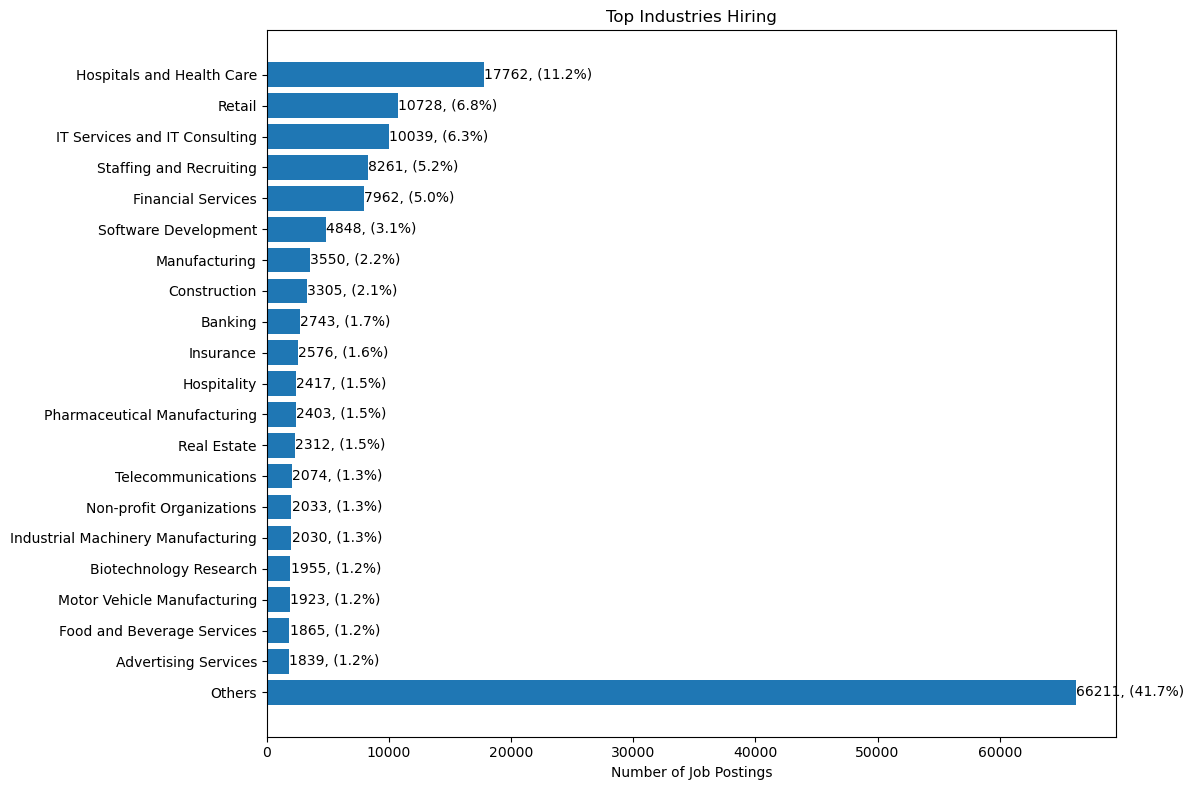

In [30]:
plot_common_categorical(df_posting_industries, "industry_name", top_n=20, title='Top Industries Hiring')

The top hiring industry is healthcare, accounting for 11.2% of all job postings. This is followed by the retail industry (6.8%) and IT services (6.3%). Recruitment agencies rank fourth, contributing 5.2% of the total postings.

#### Skills

In [31]:
# Find the most common skills required
df_posting_skills = find_common_categorical(df_final, "skill_name")

display(df_posting_skills)

,skill_name,count
0,Information Technology,25252
1,Sales,21185
2,Management,20385
3,Manufacturing,17728
4,Health Care Provider,16674
5,Business Development,13300
6,Engineering,12530
7,Other,12312
8,Finance,8008
9,Marketing,5399


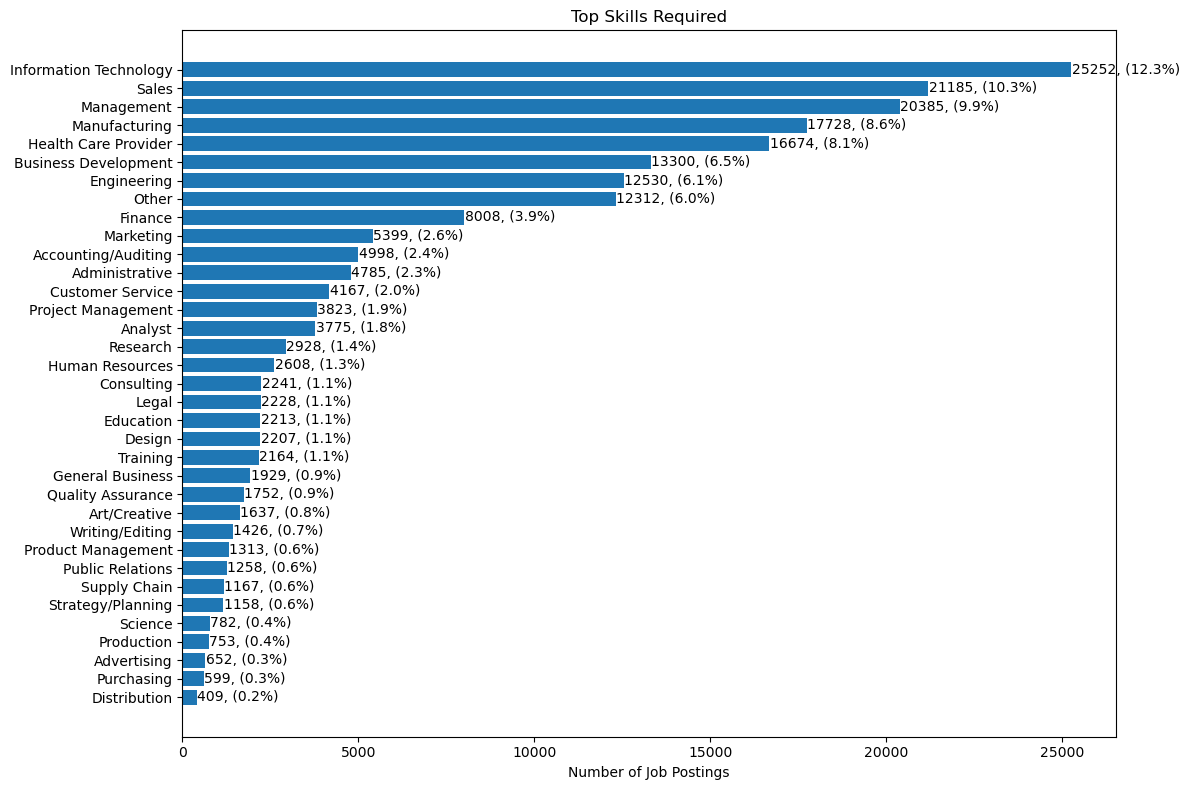

In [32]:
plot_common_categorical(df_posting_skills, "skill_name", title='Top Skills Required')

Although healthcare is the top hiring industry, the most in-demand skill set lies in IT, with 12.3% of job postings requiring it. Other highly sought-after skills in the current job market include sales, management, and manufacturing.

#### Jobs

Due to the wide variety of job titles, we apply an LLM-based transformer to encode the titles into meaningful vector representations. These embeddings are then clustered to group similar roles and facilitate the search process. To interpret the resulting clusters and understand the demand across different job categories, we use TF-IDF to extract the most representative keywords for each group.

In [33]:
# Clean job title

def clean_title(title):
    title = title.lower()
    title = re.sub(r'[^\w\s]', '', title)  # remove punctuation
    title = title.strip()
    return title

df_final['clean_title'] = df_final['title'].dropna().apply(clean_title)

##### Test Clustering Methods

In [34]:
# Apply LLM to encode the job titles into vector embeddings.

model = SentenceTransformer('all-MiniLM-L6-v2')

titles = df_final['clean_title'].fillna('').tolist()
job_embeddings = model.encode(titles, show_progress_bar=True)

# Normalize the data before clustering
job_embeddings_normed = Normalizer().fit_transform(job_embeddings)

Batches:   0%|          | 0/3870 [00:00<?, ?it/s]

In [35]:
# Reduce dimensionality for easier clustering
pca = PCA(n_components=10)
job_embeddings_normed_pca = pca.fit_transform(job_embeddings_normed)

N_cluster =  5
N_cluster =  6
N_cluster =  7
N_cluster =  8
N_cluster =  9
N_cluster =  10
N_cluster =  11
N_cluster =  12
N_cluster =  13
N_cluster =  14
N_cluster =  15
N_cluster =  16
N_cluster =  17
N_cluster =  18
N_cluster =  19
N_cluster =  20


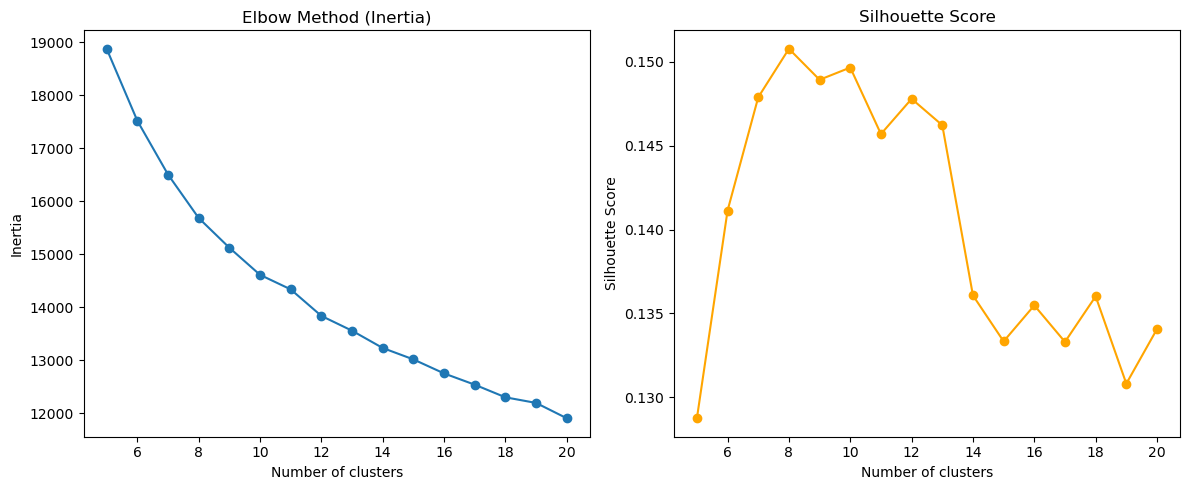

In [ ]:
# KMeans clustering

labels_kmeans = {}
results = []

k_range = range(5, 21)
for k in k_range:
    print("N_cluster = ", k)
    
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(job_embeddings_normed_pca)
    labels_kmeans[k] = labels

    results.append({
        "k": k,
        "inertia_scores": kmeans.inertia_,
        "silhouette_scores": silhouette_score(job_embeddings_normed_pca, labels)
    })

    # print(results[-1])

df_kmeans_res = pd.DataFrame(results)

# Plot the results
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(df_kmeans_res["k"], df_kmeans_res["inertia_scores"], marker='o')
axs[0].set_title("Elbow Method (Inertia)")
axs[0].set_xlabel("Number of clusters")
axs[0].set_ylabel("Inertia")

axs[1].plot(df_kmeans_res["k"], df_kmeans_res["silhouette_scores"], marker='o', color='orange')
axs[1].set_title("Silhouette Score")
axs[1].set_xlabel("Number of clusters")
axs[1].set_ylabel("Silhouette Score")

plt.tight_layout()

In [37]:
# df_kmeans_res.to_csv("kmeans_scaled_pca10_results.csv")

##### Finalize clustering method and parameters

In [38]:
k = 8
kmeans = KMeans(n_clusters=k, random_state=0)

embeddings_temp = job_embeddings_normed_pca

df_final['job_cluster'] = kmeans.fit_predict(embeddings_temp)

# Inspect results
for i in range(k):
    print(f"\n--- Cluster {i} ---")
    print(df_final[df_final['job_cluster'] == i]['clean_title'].sample(10, random_state=1).tolist())


--- Cluster 0 ---
['childrens group worker', '20242025 general resource room teacher ms  fremont ms', 'assistant property manager', 'assistant superintendent', 'event coordinator', 'paralegal', 'operations associate', 'senior associate social', 'environmental services aide', 'part time collections coordinator iii']

--- Cluster 1 ---
['lead rd fuel cell scientist', 'epic healthy planet analyst remote', 'aws lex and python developer  uscgcgcead', 'regulatory counsel automotive environmental', 'hybrid speech language pathologist  crestwood illinois', 'data modeler', 'jscape mft', 'thrive scholar summer academy web lead instructor full time summer contract', 'packager  2nd shift', 'site controller']

--- Cluster 2 ---
['client relationship consultant 2 banker  cape williams street', 'treasury analyst i', 'oracle simphony pos consultant', 'financial services representative i', 'plaintiff trial attorney', 'concierge banker', 'senior associate product management card fraud', 'financial advi

Text(0.5, 0.98, 'Silhouette analysis for KMeans clustering on sample data with n_clusters = 8, Silhouette Score = 0.151')

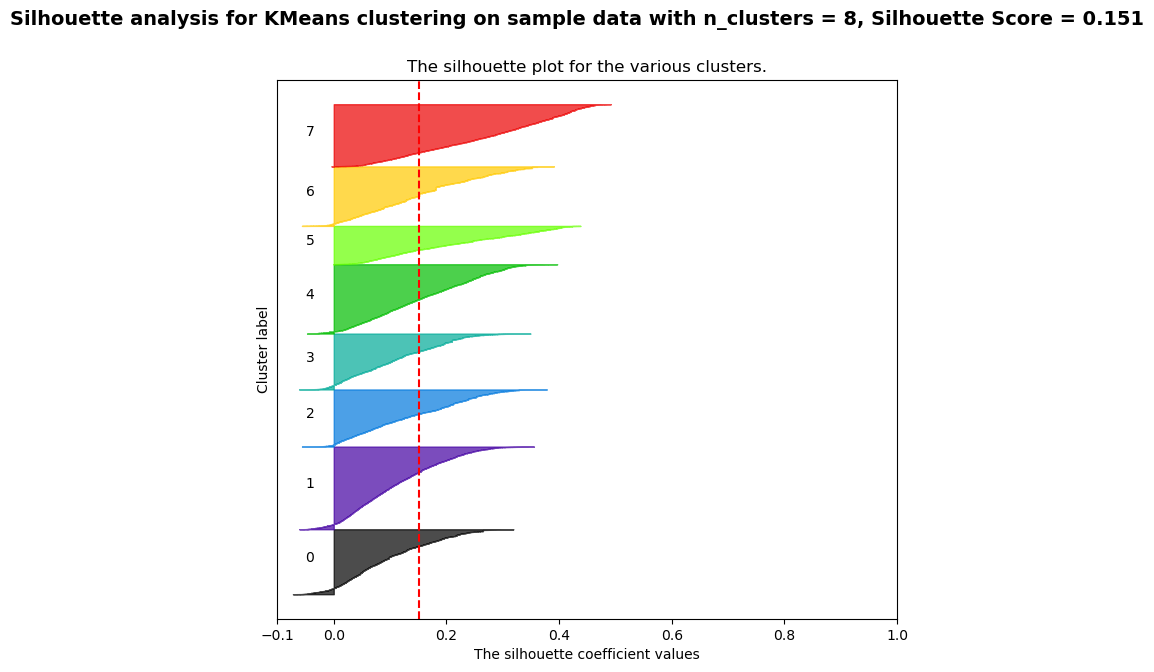

In [39]:
# Silhouette plot to understand the quality of the clustering

silhouette_avg = silhouette_score(embeddings_temp, df_final['job_cluster'])

# Compute the silhouette scores for each sample
sample_silhouette_values = silhouette_samples(embeddings_temp, df_final['job_cluster'])

fig, axs = plt.subplots(figsize=(8,7))

y_lower = 10
for i in range(k):
    # Aggregate the silhouette scores for samples belonging to
    # cluster i, and sort them
    ith_cluster_silhouette_values = sample_silhouette_values[df_final['job_cluster'] == i]

    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / k)
    axs.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    # Label the silhouette plots with their cluster numbers at the middle
    axs.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples

axs.set_title("The silhouette plot for the various clusters.")
axs.set_xlabel("The silhouette coefficient values")
axs.set_ylabel("Cluster label")

# The vertical line for average silhouette score of all the values
axs.axvline(x=silhouette_avg, color="red", linestyle="--")

axs.set_yticks([])  # Clear the yaxis labels / ticks
axs.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

fig.suptitle(
    "Silhouette analysis for KMeans clustering on sample data with n_clusters = {}, Silhouette Score = {:.3f}".format(k, silhouette_avg),
    fontsize=14,
    fontweight="bold",
) 

The silhouette plot shows that the clusters have similar thickness and hence are of similar sizes, with each of them having above average silhouette score, showing good clustering.

##### Decipher the clusters

In [40]:
clustered_titles = {}
for cluster in df_final['job_cluster'].unique():
    clustered_titles[cluster] = df_final[df_final['job_cluster']==cluster]["title"].values

In [41]:
# TF-IDF
def get_top_keywords_per_cluster(clustered_titles, top_n=5):
    top_keywords = {}
    vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))

    for cluster, titles in clustered_titles.items():
        tfidf = vectorizer.fit_transform(titles)
        mean_tfidf = tfidf.mean(axis=0).A1
        feature_names = vectorizer.get_feature_names_out()
        top_idx = mean_tfidf.argsort()[::-1][:top_n]
        top_keywords[cluster] = [feature_names[i] for i in top_idx]

    return top_keywords

top_keywords = get_top_keywords_per_cluster(clustered_titles, top_n=5) # top 5 keywords

for cluster, keywords in top_keywords.items():
    print(f"Cluster {cluster}: {' | '.join(keywords)}")

df_final["job_cluster_keywords"] = df_final["job_cluster"].map(lambda x: " | ".join(top_keywords.get(x, [])))

Cluster 6: sales | manager | sales manager | associate | representative
Cluster 7: nurse | registered | registered nurse | rn | nurse rn
Cluster 3: manager | project | project manager | operations | senior
Cluster 2: analyst | accountant | senior | business | financial
Cluster 5: technician | specialist | maintenance | service | service technician
Cluster 1: time | driver | lead | shift | operator
Cluster 4: engineer | developer | software | senior | software engineer
Cluster 0: assistant | associate | coordinator | manager | administrative


In [42]:
job_counts = df_final['job_cluster_keywords'].value_counts().reset_index()
job_counts.columns = ['job_cluster', 'count']
job_counts = job_counts.sort_values("count", ascending=False)

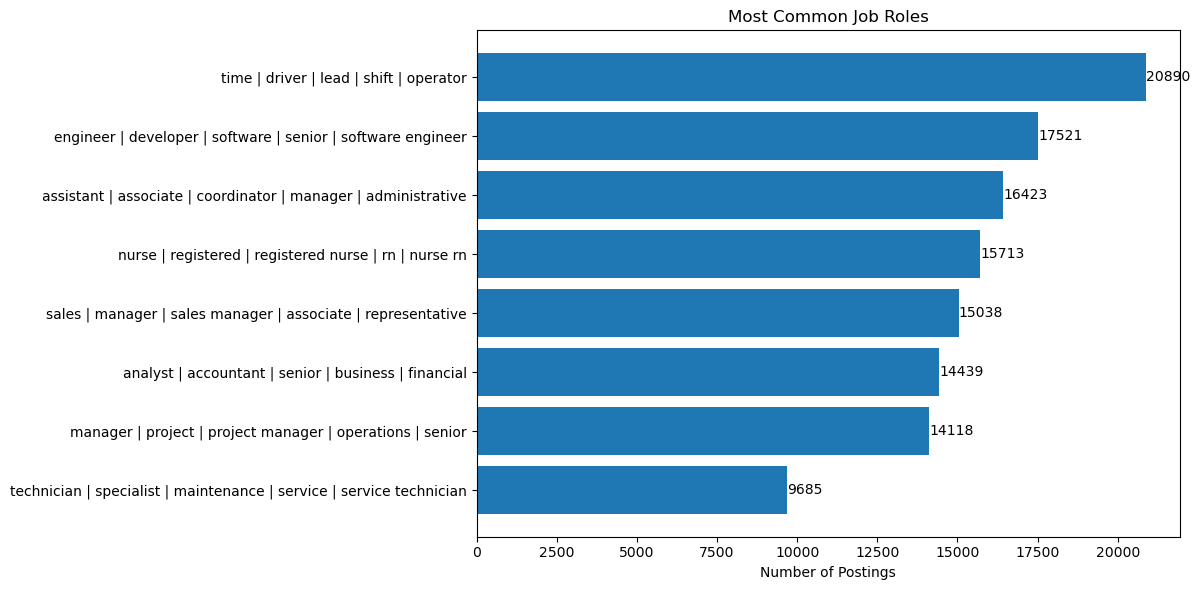

In [43]:
fig, axs = plt.subplots(figsize=(12, 6))

bars = axs.barh(job_counts['job_cluster'], job_counts['count'])
axs.set_title('Most Common Job Roles')
axs.set_xlabel('Number of Postings')
axs.invert_yaxis()

for bar, count in zip(bars, job_counts['count']):
    axs.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, str(count), va='center')

fig.tight_layout()

The most common roles appear to be blue-collar jobs such as drivers and machine operators, followed by software developers, administrative staff, and healthcare workers.

In [40]:
# # Visualize the embeddings (takes time to run)

# tsne = TSNE(n_components=2, perplexity=30, random_state=42)
# job_embeddings_2d = tsne.fit_transform(job_embeddings)

# fig, axs = plt.subplots(figsize=(10, 6))
# for label in set(df_final['job_cluster']):
#     ix = [i for i, l in enumerate(df_final['job_cluster']) if l == label]
#     print(label, len(ix))
#     # axs.scatter(job_embeddings_2d[ix, 0], job_embeddings_2d[ix, 1], label=f"Cluster {label}", alpha=0.5)

# axs.legend()
# axs.set_title("Job Title Clusters (via t-SNE)")
# axs.set_xlabel("Component 1")
# axs.set_ylabel("Component 2")
# axs.grid(True)

### Query the statistics of a role

To explore trends for a specific role, this subsection allows filtering the job postings accordingly and summarizing key insights.

In [49]:
def filter_by_role(df, query):
    query_lower = query.lower()
    return df[
        df["title"].str.lower().str.contains(query_lower) |
        df["job_cluster_keywords"].str.contains(query_lower)
    ]

In [50]:
def find_posting_stats(df):
    print("Industry Statistics:")
    display(df["industry_name"].value_counts())

    print("Top Companies:")
    display(df["company_name"].value_counts())

    print("Company Size Statistics:")
    display(df["company_size"].describe())

    def estimate_salary(row):
        if pd.notnull(row["med_salary_yearly"]):
            return row["med_salary_yearly"]
        elif pd.notnull(row["min_salary_yearly"]) and pd.notnull(row["max_salary_yearly"]):
            return (row["min_salary_yearly"] + row["max_salary_yearly"]) / 2
        else:
            return np.nan
    
    estimated_salary = df.apply(estimate_salary, axis=1)
    print("Yearly Salary Statistics:")
    display(estimated_salary.describe())

    print("pay_period:")
    display(df["pay_period"].value_counts())

    print("Work Types:")
    display(df["formatted_work_type"].value_counts())

    print("Experience Required:")
    display(df["formatted_experience_level"].value_counts())

    print("Remote Work Option:")
    display(df["remote_allowed"].value_counts())

    print("Application Statistics:")
    display(df["applies"].describe())

    print("Skills required")
    df_posting_skills = find_common_categorical(df, "skill_name")
    display(df_posting_skills)

In [51]:
role = "data analyst"

filtered_postings = filter_by_role(df_final, role)
find_posting_stats(filtered_postings)

Industry Statistics:


industry_name
IT Services and IT Consulting                                                92
Software Development; Computer and Network Security; Engineering Services    35
Software Development                                                         19
Financial Services                                                           18
Staffing and Recruiting                                                      18
                                                                             ..
Software Development; IT System Custom Software Development                   1
Banking                                                                       1
Hospitals and Health Care; Data Infrastructure and Analytics                  1
Aviation and Aerospace Component Manufacturing                                1
Computer Networking Products                                                  1
Name: count, Length: 120, dtype: int64

Top Companies:


company_name
DataAnnotation                           37
ATC                                      18
TELUS International                      11
TELUS International AI Data Solutions    10
Coders Data                               7
                                         ..
Brooksource                               1
HRUCKUS                                   1
MITRE                                     1
IBM                                       1
Huntress                                  1
Name: count, Length: 277, dtype: int64

Company Size Statistics:


...

remote_allowed
0    259
1    149
Name: count, dtype: int64

Application Statistics:


count    408.000000
mean      23.034314
std       51.914348
min        0.000000
25%        0.000000
50%        3.000000
75%       20.250000
max      378.000000
Name: applies, dtype: float64

Skills required


,skill_name,count
0,Information Technology,287
1,Analyst,138
2,Research,58
3,Engineering,46
4,Other,20
5,Finance,12
6,Marketing,10
7,Quality Assurance,10
8,Administrative,6
9,Business Development,5


As expected, data analyst roles are most commonly found in the **IT and software development industries**. The hiring companies tend to be **moderate in size**, and the average annual salary for these positions is approximately **$105,000**. In terms of job types, **over half of the roles are full-time**, while around 40% are contract-based.

The most commonly required experience levels are **mid-senior and entry level**, indicating opportunities for both early-career professionals and those with more experience. Reflecting the digital nature of the work, **36% of data analyst roles offer remote work options**, significantly higher than the overall average of 12% across all roles.

On average, each posting receives about 23 applications, suggesting a moderately competitive landscape. The most in-demand skill sets include **IT, data analysis, and research**, which aligns with expectations for this role.

In [52]:
role = "nurse"

filtered_postings = filter_by_role(df_final, role)
find_posting_stats(filtered_postings)

Industry Statistics:


industry_name
Hospitals and Health Care                                                                   9112
Staffing and Recruiting                                                                     2084
Mental Health Care                                                                           279
Higher Education                                                                             216
Medical Practices                                                                            170
                                                                                            ... 
Civic and Social Organizations; Health and Human Services; Hospitals and Health Care           1
Education; Civic and Social Organizations                                                      1
Data Infrastructure and Analytics                                                              1
Machinery Manufacturing                                                                        1
Hospitals and He

Top Companies:


company_name
Liberty Healthcare and Rehabilitation Services    1078
CareerStaff Unlimited                              319
The Job Network                                    319
Solomon Page                                       247
Life Care Centers of America                       209
                                                  ... 
TSR Consulting Services, Inc.                        1
KGH Autism Services                                  1
GQR Healthcare                                       1
Hub Technology Group                                 1
CORA Health Services                                 1
Name: count, Length: 2445, dtype: int64

Company Size Statistics:


...

remote_allowed
0    14824
1      900
Name: count, dtype: int64

Application Statistics:


count    15724.000000
mean         0.324536
std          4.904137
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        360.000000
Name: applies, dtype: float64

Skills required


,skill_name,count
0,Health Care Provider,12234
1,Other,1549
2,Information Technology,606
3,Management,417
4,Research,401
5,Analyst,361
6,Manufacturing,285
7,Administrative,271
8,Sales,261
9,Business Development,195


As expected, nursing roles are predominantly found in the healthcare industry, with Liberty Healthcare and Rehabilitation Services emerging as the top hiring company. The median annual salary for nursing positions is approximately $88,000. Most roles are full-time, and the most commonly required experience levels are mid-senior and entry level, both appearing in comparable proportions.

Given the hands-on nature of nursing work, only about 5% of the roles offer remote working options. Interestingly, these postings receive relatively few applications on average, highlighting a significant shortage of healthcare workers. The most in-demand skill set for these roles is healthcare provision, reflecting the practical and clinical requirements of the job.

## Task 5 - Find the most suitable role for a candidate profile

To assist the recruitment agency in identifying suitable roles for a candidate, this section allows users to input a candidate profile and automatically shortlist relevant job postings.

In [53]:
def filter_jobs(df_postings, profile):
    df = df_postings.copy()

    # Desired job title
    if profile.get("desired_job"):
        keyword = profile["desired_job"].lower()
        df = df[ (df["job_cluster_keywords"].str.lower().str.contains(keyword)) | (df["title"].str.lower().str.contains(keyword)) ]

    # Location
    if profile.get("preferred_location"):
        loc = profile["preferred_location"]
        df = df[df["location"].str.contains(loc)]

    # Salary
    if profile.get("expected_salary"):
        df = df[ (df["med_salary_yearly"] >= profile["expected_salary"]) | (df["max_salary_yearly"] >= profile["expected_salary"]) ]

    # Work type
    if profile.get("desired_work_type"):
        work_type = profile["desired_work_type"]
        df = df[df["formatted_work_type"] == work_type]

    # Experience level
    if profile.get("desired_experience_level"):
        level = profile["desired_experience_level"]
        df = df[df["formatted_experience_level"] == level]

    # Remote
    if profile.get("preferred_remote"):
        remote = (int)(profile["preferred_remote"])
        df = df[df["remote_allowed"]==remote]

    # Skills (intersection-based filtering)
    if profile.get("skills"):
        profile_skills = set(s.lower() for s in profile["skills"])
        
        def has_overlap(job_skills):
            if pd.isnull(job_skills):
                return False
            job_skill_set = set([s.lower().strip() for s in job_skills.split(";")])
            return not profile_skills.isdisjoint(job_skill_set)

        df = df[df["skill_name"].apply(has_overlap)]

        df['skill_set'] = df['skill_name'].apply(lambda x: set([s.lower().strip() for s in x.split(';')]))
        df["matched_skill_percentage"] = df['skill_set'].apply(lambda x: int(len(profile_skills & x) / len(x) * 100))
        df.drop(["skill_set"], axis=1)

    # Industry
    if profile.get("preferred_industry"):
        ind = profile["preferred_industry"].lower()
        df = df[ (df['industry_name'].notna()) & (df["industry_name"].str.lower().str.contains(ind)) ]

    return df

In [54]:
# Find most suitable roles for a candidate

candidate_profile = {
    "desired_job": "Engineer",
    "preferred_location": "NY",
    "expected_salary": 100000,
    "desired_work_type": "Full-time",
    "desired_experience_level": "Mid-Senior level",
    "preferred_remote": False,
    "skills": {"Analyst", "Engineering", "Management"},
    "preferred_industry": "Medical"
}

filtered_jobs = filter_jobs(df_final, candidate_profile)

filtered_jobs[["title", "job_cluster_keywords", "industry_name", "location",
               "min_salary_yearly", "med_salary_yearly", "max_salary_yearly",
               "formatted_work_type", "formatted_experience_level", "remote_allowed", "skill_name", "matched_skill_percentage"]]

,title,job_cluster_keywords,industry_name,location,min_salary_yearly,med_salary_yearly,max_salary_yearly,formatted_work_type,formatted_experience_level,remote_allowed,skill_name,matched_skill_percentage
1869,Sr Programmer Analyst Oracle EBS,engineer | developer | software | senior | sof...,Medical Equipment Manufacturing,"Victor, NY",104000.0,NaN,139588.0,Full-time,Mid-Senior level,0,Engineering; Information Technology,50
94295,Senior Process Development Engineer,engineer | developer | software | senior | sof...,Medical Device,"Clarence, NY",90750.0,NaN,133100.0,Full-time,Mid-Senior level,0,Engineering; Information Technology,50
114199,Senior Product Development Engineer,engineer | developer | software | senior | sof...,Medical Equipment Manufacturing,"Orchard Park, NY",95000.0,NaN,135000.0,Full-time,Mid-Senior level,0,Design; Engineering; Manufacturing,33


In [55]:
# Find most suitable roles for a candidate

candidate_profile = {
    "desired_job": "Nurse",
    "preferred_location": "FL",
    "expected_salary": 60000,
    "skills": {"Healthcare", "Administrative"},
}

filtered_jobs = filter_jobs(df_final, candidate_profile)

filtered_jobs[["title", "job_cluster_keywords", "industry_name", "location",
               "min_salary_yearly", "med_salary_yearly", "max_salary_yearly",
               "formatted_work_type", "formatted_experience_level", "remote_allowed", "skill_name", "matched_skill_percentage"]]

,title,job_cluster_keywords,industry_name,location,min_salary_yearly,med_salary_yearly,max_salary_yearly,formatted_work_type,formatted_experience_level,remote_allowed,skill_name,matched_skill_percentage
20451,Admissions Coordinator / Phone Representative ...,nurse | registered | registered nurse | rn | n...,Hospitals and Health Care,"Pembroke Pines, FL",80000.0,NaN,135000.0,Full-time,NaN,0,Administrative,100
21815,Licensed Nursing Home Administrator,nurse | registered | registered nurse | rn | n...,Hospitals and Health Care,"Palm Beach County, FL",160000.0,NaN,170000.0,Full-time,NaN,0,Health Care Provider; Administrative; Business...,33
42202,Clinical Research Coordinator - 225139,nurse | registered | registered nurse | rn | n...,Research Services,"Boca Raton, FL",41600.0,NaN,66560.0,Contract,NaN,0,Research; Administrative,50
114769,Nursing Home Administrator,nurse | registered | registered nurse | rn | n...,Hospitals and Health Care,"Crystal River, FL",120000.0,NaN,138000.0,Full-time,Executive,0,Administrative; Finance; Management,33


These examples demonstrate the system’s ability to suggest suitable roles based on a candidate’s profile and requirements.